In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans



In [77]:
catlog = pd.read_csv("Audible_Catlog.csv")
features = pd.read_csv("Audible_Catlog_Advanced_Features.csv")

print("catlog shape:", catlog.shape)
print("features shape:", features.shape)

catlog.head()
features.head()

print(catlog.columns)
print(features.columns)

catlog shape: (6368, 5)
features shape: (4464, 8)
Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price'], dtype='object')
Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='object')


In [78]:
df = pd.merge(catlog, features, on="Book Name", how="inner")

print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removal:", df.shape)

df['Number of Reviews_x'] = df['Number of Reviews_x'].fillna('')
df['Number of Reviews_y'] = df['Number of Reviews_y'].fillna('')
df['Price_x'] = df['Price_x'].fillna('')
df['Description'] = df['Description'].fillna('')

print(df.isnull().sum())

Duplicate rows: 646
After removal: (3624, 12)
Book Name              0
Author_x               0
Rating_x               0
Number of Reviews_x    0
Price_x                0
Author_y               0
Rating_y               0
Number of Reviews_y    0
Price_y                0
Description            0
Listening Time         0
Ranks and Genre        0
dtype: int64


In [79]:
df.columns = df.columns.str.strip().str.lower()

df.rename(columns={
    'book name': 'title',
    'author_x': 'author',
    'author_y': 'author_dup',
    'rating_x': 'rating',
    'rating_y': 'rating_dup',
    'number of reviews_x': 'reviews',
    'number of reviews_y': 'reviews_dup',
    'price_x': 'price',
    'price_y': 'price_dup',
    'ranks and genre': 'genre'
}, inplace=True)

text_cols = ['title', 'author', 'author_dup', 'description', 'genre']

for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

df.drop(columns=['author_dup', 'rating_dup', 'reviews_dup', 'price_dup'], inplace=True)

print(df.columns)
df.head()



Index(['title', 'author', 'rating', 'reviews', 'price', 'description',
       'listening time', 'genre'],
      dtype='object')


,title,author,rating,reviews,price,description,listening time,genre
0,think like a monk: the secret of how to harnes...,jay shetty,4.9,313.0,10080.0,"over the past three years, jay shetty has beco...",10 hours and 54 minutes,",#1 in audible audiobooks & originals (see top..."
1,ikigai: the japanese secret to a long and happ...,héctor garcía,4.6,3658.0,615.0,brought to you by penguin.,3 hours and 23 minutes,",#2 in audible audiobooks & originals (see top..."
2,the subtle art of not giving a f*ck: a counter...,mark manson,4.4,20174.0,10378.0,"in this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in audible audiobooks & originals (see top..."
3,atomic habits: an easy and proven way to build...,james clear,4.6,4614.0,888.0,brought to you by penguin.,5 hours and 35 minutes,",#5 in audible audiobooks & originals (see top..."
4,life's amazing secrets: how to find balance an...,gaur gopal das,4.6,4302.0,1005.0,"stop going through life, start growing throug...",6 hours and 25 minutes,",#6 in audible audiobooks & originals (see top..."


In [80]:
print(df.duplicated(subset=["title", "author"]).sum())

269


In [81]:
duplicates = df[df.duplicated(subset=["title", "author"], keep=False)]
duplicates[["title", "author", "rating"]].sort_values(by=["title", "author"]).head(20)

,title,author,rating
2987,#girlboss,sophia amoruso,4.5
2988,#girlboss,sophia amoruso,4.5
940,10 essential pieces of literature,khalil gibran,-1.0
941,10 essential pieces of literature,khalil gibran,-1.0
3657,101 fairy tales book,dreamland publications,4.3
3658,101 fairy tales book,dreamland publications,4.3
1527,2001: a space odyssey,arthur c. clarke,4.6
1528,2001: a space odyssey,arthur c. clarke,4.6
1880,a concise history of modern india,barbara metcalf,3.9
1881,a concise history of modern india,barbara metcalf,3.9


In [82]:
df = df.drop_duplicates(subset=["title", "author"]).reset_index(drop=True)
print(df.duplicated(subset=["title", "author"]).sum())
df.to_csv("cleaned_books_data.csv", index=False)


0


In [83]:
def extract_category(text):
    if pd.isna(text):
        return "unknown"
    
    # Extract text after "in"
    match = re.search(r'in (.*?)(\(|$)', text)
    
    if match:
        return match.group(1).lower().strip()
    else:
        return "unknown"

df['clean_genre'] = df['genre'].apply(extract_category)

df['clean_genre'].head(10)

0    audible audiobooks & originals
1    audible audiobooks & originals
2    audible audiobooks & originals
3    audible audiobooks & originals
4    audible audiobooks & originals
5    audible audiobooks & originals
6    audible audiobooks & originals
7    audible audiobooks & originals
8    audible audiobooks & originals
9    audible audiobooks & originals
Name: clean_genre, dtype: object

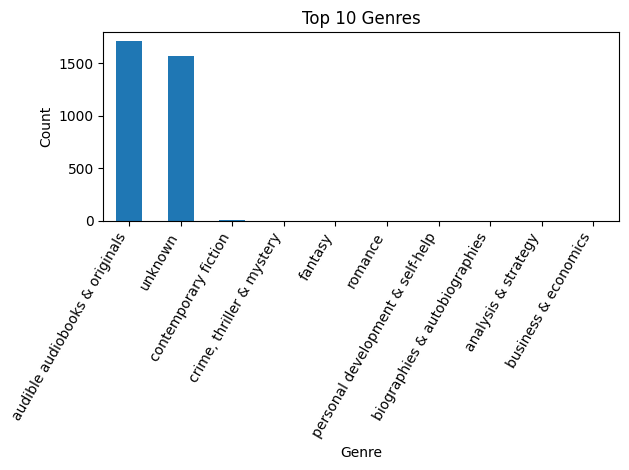

In [84]:
top_genres = df['clean_genre'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [85]:
df['content'] = (
    df['title'] + " " +
    df['author'] + " " +
    df['description']
)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove special chars
    return text

df['content'] = df['content'].apply(clean_text)

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['content'])

print(tfidf_matrix.shape)

(3355, 5000)


In [86]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_books(book_title):
    book_title = book_title.lower()
    
    matches = df[df['title'].str.contains(book_title)]
    
    if matches.empty:
        suggestions = df[df['title'].str.contains(book_title[:3])]
        return suggestions['title'].head(5).values
    
    idx = matches.index[0]
    
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]
    
    book_indices = [i[0] for i in scores]
    
    return df[['title', 'author', 'rating']].iloc[book_indices]

recommend_books("rich")

,title,author,rating
827,rich dad's increase your financial iq: get sma...,robert t. kiyosaki,4.6
143,rich dad's guide to investing: what the rich i...,robert t. kiyosaki,4.5
2612,rich dad advisors: start your own corporation:...,garrett sutton,4.6
2812,banker to the poor: micro-lending and the batt...,muhammad yunus,4.6
1243,"rich dad advisors: tax-free wealth, 2nd editio...",tom wheelwright,4.7


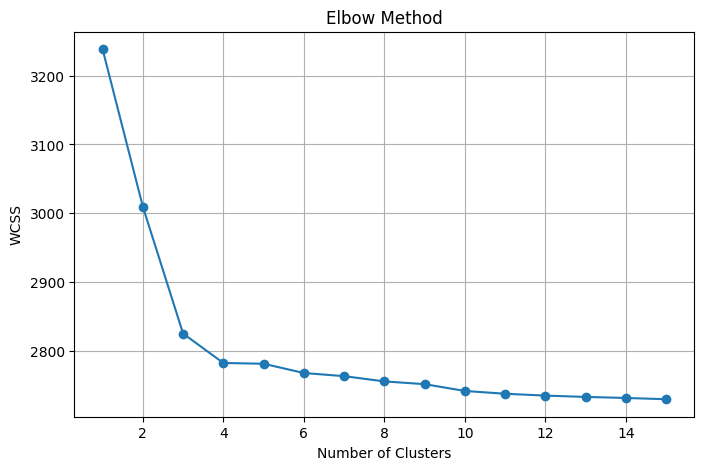

In [87]:
wcss = []

for k in range(1, 16):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(tfidf_matrix)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,16), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [88]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):  # Starts from 2 because silhouette score cannot be computed for K=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(tfidf_matrix)

    score = silhouette_score(tfidf_matrix, labels)
    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.0554
K=3, Silhouette Score=0.0877
K=4, Silhouette Score=0.0955
K=5, Silhouette Score=0.0905
K=6, Silhouette Score=0.0921
K=7, Silhouette Score=0.0923
K=8, Silhouette Score=0.0968
K=9, Silhouette Score=0.0970
K=10, Silhouette Score=0.0975


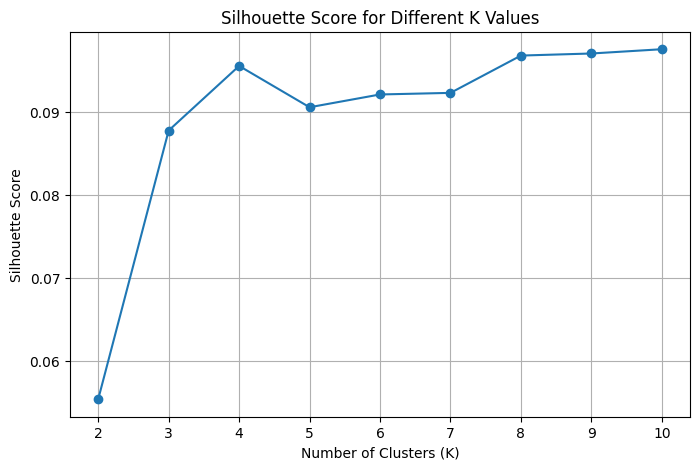

In [89]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid(True)
plt.show()

In [90]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(tfidf_matrix)

df[['title', 'cluster']].head()

def recommend_by_cluster(book_title):
    book_title = book_title.lower()
    
    if book_title not in df['title'].values:
        return "Book not found"
    
    cluster_id = df[df['title'] == book_title]['cluster'].values[0]
    
    return df[df['cluster'] == cluster_id]['title'].head(5)

In [91]:
def recommend_content(title, k=5):
    title = title.lower()
    matches = df[df['title'].str.contains(title)]
    if matches.empty:
        return []
    
    idx = matches.index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:k+1]
    
    idxs = [i for i,_ in scores]
    return df[['title','author','rating']].iloc[idxs].reset_index(drop=True)

In [92]:
def recommend_cluster(title, k=5):
    title = title.lower()
    matches = df[df['title'].str.contains(title)]
    if matches.empty:
        return []
    
    idx = matches.index[0]
    cluster_id = df.loc[idx, 'cluster']
    
    recs = df[df['cluster'] == cluster_id]
    recs = recs[recs.index != idx]  # remove same book
    
    return recs[['title','author','rating']].head(k).reset_index(drop=True)

In [93]:
def recommend_hybrid(title, k=5):

    content = recommend_content(title, k)
    cluster = recommend_cluster(title, k)

    hybrid = content.head(3).copy()

    for _, row in cluster.iterrows():
        if row["title"] not in hybrid["title"].values:
            hybrid = pd.concat(
                [hybrid, row.to_frame().T],
                ignore_index=True
            )

        if len(hybrid) >= k:
            break

    return hybrid.reset_index(drop=True)

In [94]:
def precision_at_k(recommended, relevant, k=5):
    recommended = list(recommended)[:k]
    relevant = set(relevant)
    
    hits = len([r for r in recommended if r in relevant])
    return hits / k

In [95]:
def recall_at_k(recommended, relevant, k=5):
    recommended = list(recommended)[:k]
    relevant = set(relevant)
    
    hits = len([r for r in recommended if r in relevant])
    return hits / len(relevant) if len(relevant) > 0 else 0

In [96]:
book = "rich"

# recommendations
content_rec = recommend_content(book)['title']
cluster_rec = recommend_cluster(book)['title']
hybrid_rec = recommend_hybrid(book)['title']

# define relevant set (same cluster)
idx = df[df['title'].str.contains(book)].index[0]
cluster_id = df.loc[idx, 'cluster']
relevant_books = df[df['cluster'] == cluster_id]['title']

content_prec = precision_at_k(content_rec, relevant_books)
cluster_prec = precision_at_k(cluster_rec, relevant_books)
hybrid_prec = precision_at_k(hybrid_rec, relevant_books)

content_recall = recall_at_k(content_rec, relevant_books)
cluster_recall = recall_at_k(cluster_rec, relevant_books)
hybrid_recall = recall_at_k(hybrid_rec, relevant_books)


In [97]:
models = ["Content-Based", "Cluster-Based", "Hybrid"]
precision = [content_prec, cluster_prec, hybrid_prec]
recall = [content_recall, cluster_recall, hybrid_recall]

f1 = [
    2 * p * r / (p + r) if (p + r) > 0 else 0
    for p, r in zip(precision, recall)
]

comparison_df = pd.DataFrame({
    "Model": models,
    "Precision@5": precision,
    "Recall@5": recall,
    "F1@5": f1
})

comparison_df

,Model,Precision@5,Recall@5,F1@5
0,Content-Based,0.4,0.000923,0.001842
1,Cluster-Based,1.0,0.002307,0.004604
2,Hybrid,0.6,0.001384,0.002762
